# Calculating energy level spacing in strongly correlated systems using tensor-compressed QPE
**Combine tensor-network compression and Fire Opal to run QPE-type algorithms**

Calculating spectral properties such as energy gaps in quantum many-body systems is one of the most promising applications of quantum computing. These gaps correspond to the allowed excitations of the system, and many quantitative predictions of practical interest, such as relaxation rates and reaction rates, depend on their accurate determination. Quantum phase estimation (QPE) algorithms can in principle determine eigenvalues with polynomial cost, but the circuit depths required have limited experimental implementations to only a few qubits on current noisy devices.

In this application note, based on [Kanno et al. (2026)](https://arxiv.org/abs/2601.15616), you will see how tensor-network circuit compression can be combined with [Fire Opal](https://docs.q-ctrl.com/fire-opal) to execute the core quantum phase-difference estimation (QPDE) signal-reconstruction workflow on hardware. The full end-to-end energy-gap extraction workflow, including longer time series and algorithmic error mitigation for larger systems, is discussed in the original paper.

Specifically, this application note covers:

* An overview of the Quantum Phase-Difference Estimation (QPDE) algorithm
* Exemplary construction of the QPDE circuit for a 4-site one-dimensional Hubbard model
* Extraction of the complex QPDE time-series signal
* A hardware comparison showing improved retained signal amplitude using Fire Opal relative to a standard Qiskit execution without Fire Opal


## 1. Introduction

### 1.1 The energy gap problem

Energy gaps, the differences between eigenvalues of a quantum Hamiltonian, encode critical physical information: excitation spectra, phase transitions, and transport properties. Classically, exact diagonalization (ED) or the full configuration interaction (FCI) method scales exponentially with system size, restricting fully exact treatments to small problem sizes. QPE-type algorithms offer a polynomial-cost alternative on a quantum computer, but their use on current devices is limited by hardware noise that accumulates over the required large gate depth.

Time-series approaches to QPE extract the phase $\Theta$ from a signal $\{e^{i\Theta t}\}$ sampled at multiple times $t$, and then apply classical signal processing (Fourier transform, convolution, or direct data fitting) to recover $\Theta$. These approaches reduce circuit depth compared to textbook QPE, but the resulting circuits remain too deep on current hardware to preserve the reconstructed signal without further compression and error suppression.

### 1.2 Quantum phase-difference estimation

The QPDE algorithm targets the energy gap $\Delta = E_1 - E_0$ between the ground state and the first excited state of the system Hamiltonian directly, without requiring a controlled time-evolution operator, which is a significant simplification over standard QPE. The algorithm prepares a superposition of the ground state $|\psi_g\rangle$ and the first excited state $|\psi_{\text{ex}}\rangle$, evolves it under the Hamiltonian, and reads out the resulting phase oscillation. Under time evolution, the two components acquire a relative phase that grows at rate $\Delta$, and reversing the preparation maps that oscillation into the all-zeros measurement probability.

To turn that oscillation into a complex signal suitable for frequency analysis, the system superposition is entangled with an ancilla qubit in its computational basis. A single-qubit phase gate on the ancilla provides a controllable phase offset $\theta$, and four measurements at $\theta = 0,\,\pi/2,\,\pi,\,3\pi/2$ reconstruct the full complex time-series signal $s_t$.

The circuit then has four steps:

1. $U_{\text{prep}}$ entangles the ancilla in its computational basis with the ground and first excited state of the modeled system:
$$U_{\text{prep}} |0\rangle^{\otimes N+1} = \frac{1}{\sqrt{2}} ( |0\rangle |\psi_g\rangle + |1\rangle |\psi_{\text{ex}}\rangle ).$$
2. Time evolution $U_{\text{evol}}^{t/\Delta t}$ acts on the system qubits.
3. A phase gate $P(\theta)$ on the ancilla introduces the offset $\theta$.
4. $U^\dagger_{\text{prep}}$ undoes the preparation; an all-zeros measurement returns the probability $m(\theta)$.

Combining the four measurements yields the signal

$$s_t =  m(0) - m(\pi) - i\left[m\!\left(\tfrac{\pi}{2}\right) - m\!\left(\tfrac{3\pi}{2}\right)\right] \approx e^{-i\Delta t},$$

so for perfectly prepared initial states $s_t$ oscillates purely at the target gap $\Delta$. The gap is then extracted by applying classical frequency estimation to $s_t$ over a long enough time window.

The implementation introduces two approximations. First, the exact ground and first excited states are not available, so they are approximated by matrix product states (MPS), obtained from the density matrix renormalization group (DMRG). An MPS is a tensor-network representation of a wavefunction as a chain of local tensors, suited to one-dimensional systems with mostly local entanglement. DMRG is a classical variational method that finds accurate MPS approximations of low-energy wavefunctions for such systems. Second, exact time evolution under the system Hamiltonian produces a deep circuit, so $U_{\text{evol}}$ is itself approximated by a shallow tensor-network-compressed brick-wall circuit.

### 1.3 The computation pipeline

The figure below visualizes the QPDE algorithm. Ground and excited states are obtained via DMRG, with the resulting MPS used directly as the reference for the state-preparation compression. The Trotter-decomposed time-evolution operator and the state-preparation unitary are each compressed into brick-wall circuits of nearest-neighbor two-qubit gates through MPS/MPO optimization. For each time step $t$, four circuits (one per phase-gate angle $\theta$) are submitted to IBM hardware through Fire Opal. In the full QPDE workflow presented in the paper, the resulting time-series signal is processed classically to estimate the energy gap. In this application note, you focus on the hardware signal-reconstruction stage and compare the retained amplitude of the reconstructed signal against a noiseless reference.

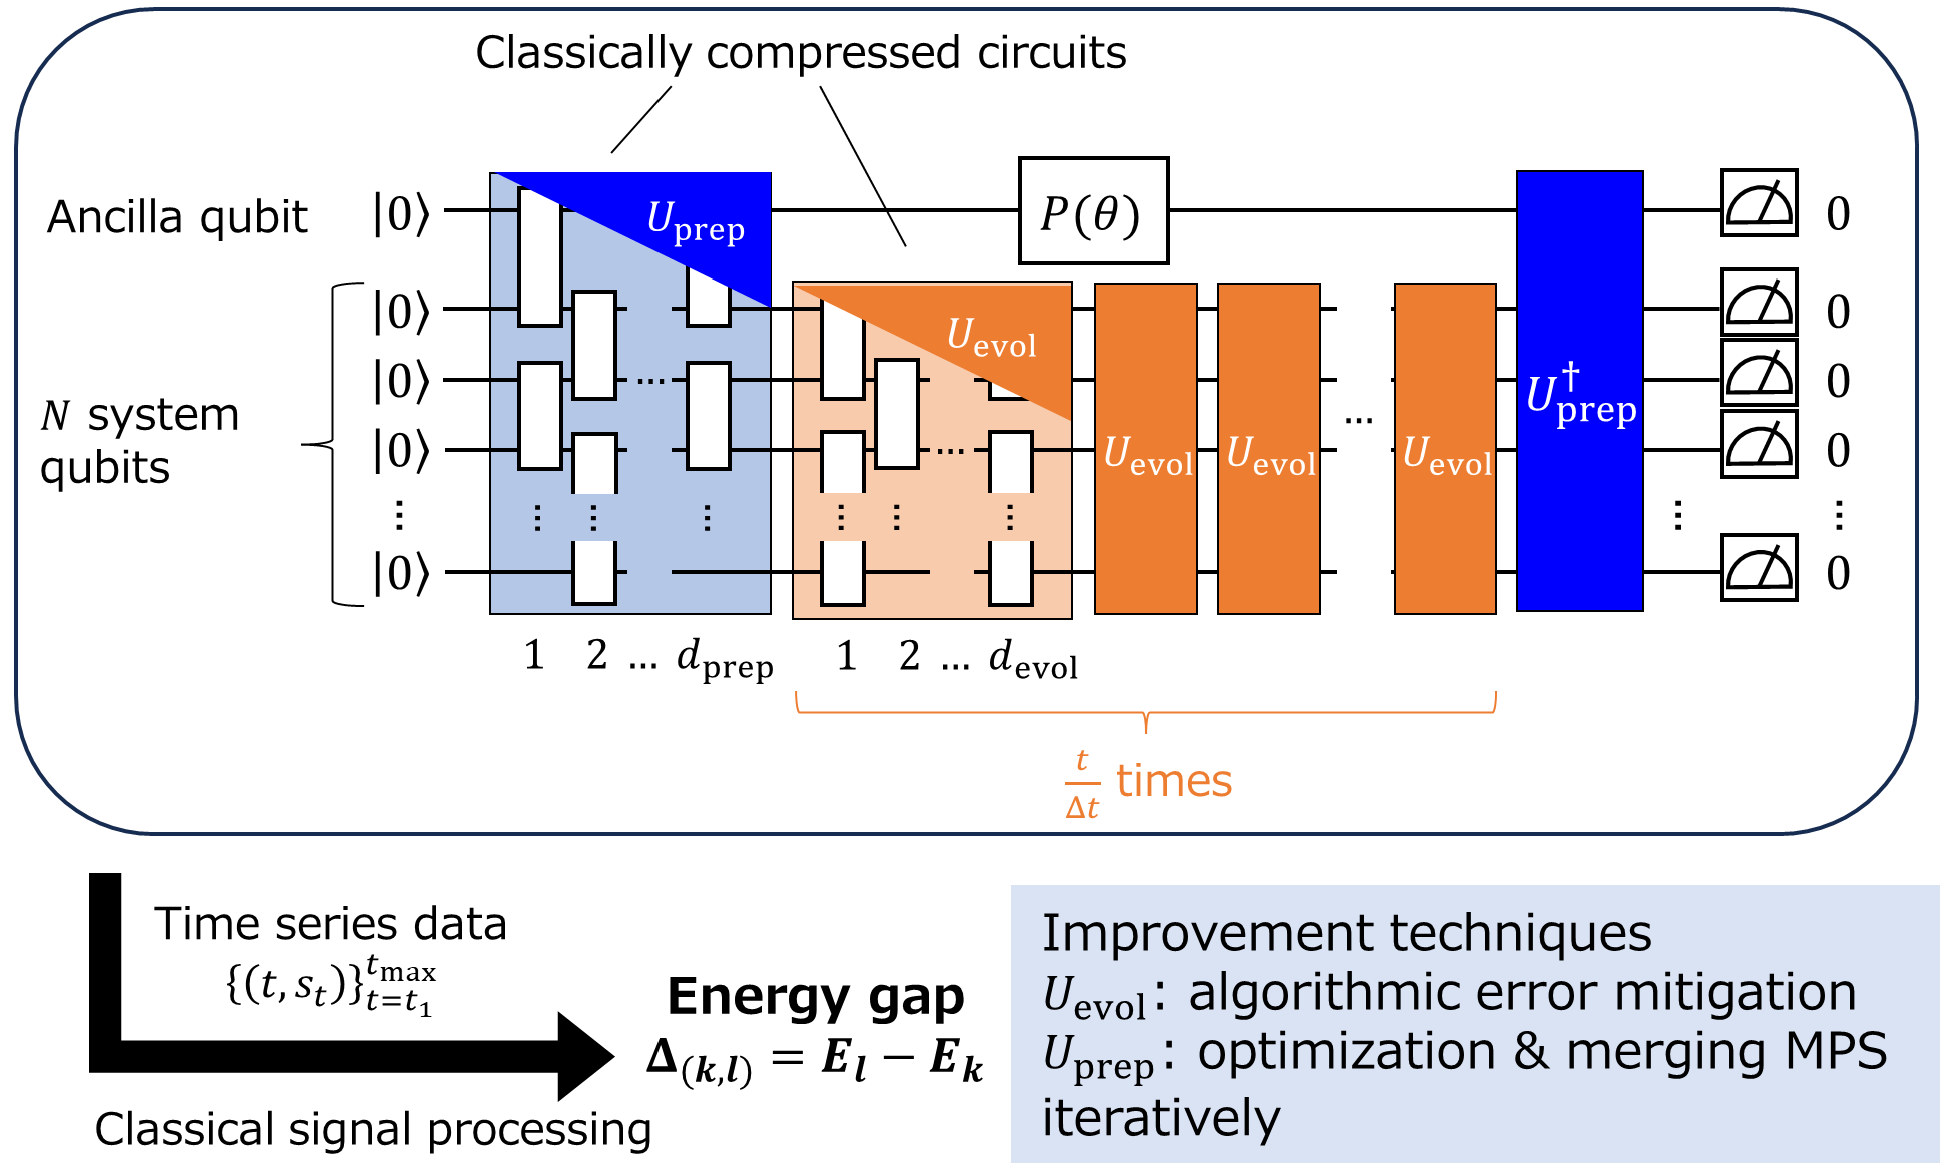

Figure 1: Overview of the tensor-based QPDE algorithm. The circuit applies $U_{\text{prep}}$ on all qubits, $U_{\text{evol}}$ repeated $t/\Delta t$ times on the system qubits, a phase gate $P(\theta)$ on the ancilla, and $U^\dagger_{\text{prep}}$, followed by all-zeros measurement. Both $U_{\text{prep}}$ and $U_{\text{evol}}$ are brick-wall circuits obtained by tensor-network compression. The energy gap $\Delta$ is extracted from the measured time-series data with classical signal processing.

### 1.4 Tensor-network circuit compression

QPDE requires two unitaries to be executed on the quantum computer: a state preparation $U_{\text{prep}}$ that creates the ancilla-system superposition, and a time-evolution operator $U_{\text{evol}}$ that implements one step of $e^{-iH\Delta t}$. A direct implementation of either would produce a circuit too deep for current hardware. Tensor-network compression reduces that depth by constructing a much shallower circuit with approximately the same action.

A standard technique to approximate a time-evolution operator is Trotterization, where $e^{-iH\Delta t}$ is broken into a product of exponentials of local terms in $H$. We use the second-order Trotter approximation with $m$ time slices to define a reference operator $U_{\text{ref}}^\dagger = S_2(-\Delta t/m)^m$. $U_{\text{ref}}^\dagger$ is represented classically as a matrix product operator (MPO), the operator analogue of an MPS. The task is then to find a brick-wall circuit, whose ansatz consists of alternating layers of nearest-neighbor two-qubit unitaries as in Figure 2(a), whose action on the relevant subspace matches that of the MPO.

The match is found by a contraction scheme sketched in Figure 2(b). Each two-qubit unitary of the ansatz is updated one at a time: treating that gate as the unknown, the surrounding circuit is contracted against the MPO reference into an environment tensor $G'$. From the singular value decomposition $G' = U S V^\dagger$ you can extract the best unitary update $G_{\text{opt}} = U V^\dagger$ by setting all singular values to 1. The approximation of the state initialization is conceptually similar and can be found in [Kanno et al. (2026)](https://arxiv.org/abs/2601.15616)


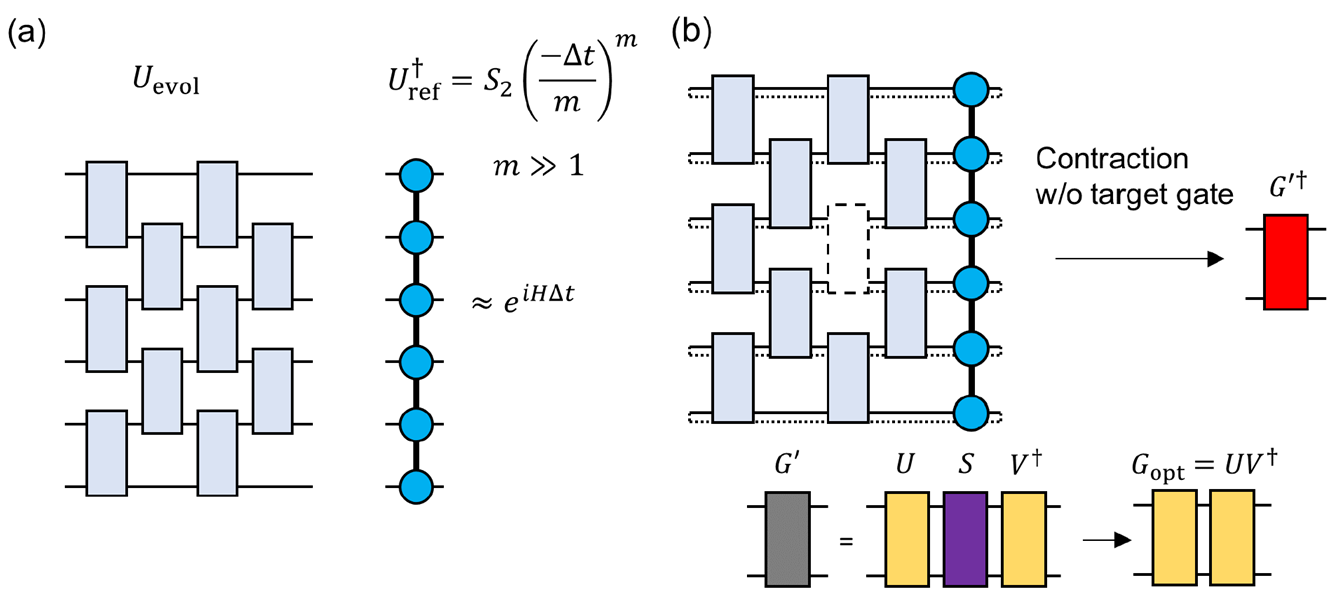

Figure 2: Circuit optimization by tensor compression. (a) Brick-wall circuit ansatz for $U_{\text{evol}}$ and MPO approximation of trotterized time evolution. (b) Tensor product compression reduces full circuit to a four-legged tensor $G^{\prime\dagger}$ by iteratively leaving out two-qubit unitaries from the brick-layer ansatz. This tensor is approximated by setting all singular values to 1 yielding $G_\text{opt}$. 

## 2. Target System: One-Dimensional Hubbard Model

The benchmark system is the one-dimensional Hubbard model:

$$H = -T \sum_{q=1}^{n_s-1} \sum_{\sigma \in \{\uparrow,\downarrow\}} \left(a^{\dagger}_{q+1,\sigma}\, a_{q,\sigma} + \text{h.c.}\right) + U \sum_{q=1}^{n_s} n_{q\uparrow}\, n_{q\downarrow} - \frac{U}{2} \sum_{q=1}^{n_s} (n_{q\uparrow} + n_{q\downarrow}),$$

with hopping $T = 1$, on-site Coulomb energy $U = 10$ (strong-correlation regime), and Jordan-Wigner fermion-to-qubit mapping with an up-down qubit ordering ($1\!\uparrow, 1\!\downarrow, 2\!\uparrow, \ldots, n_s\!\downarrow$). The number of system qubits is $N = 2n_s$.

The code below reproduces the 4-site system ($N = 8$ system qubits, 9 total with the ancilla). The reference energy gap from exact diagonalization is $\Delta^{\text{ref}}_{(0,1)} = 0.254$.

## 3. Fire Opal execution

The QPDE signal $s_t$ is reconstructed from the measurement probability of a single bitstring, namely the all-zeros outcome. This is a useful scalability property of the algorithm: the shot budget needed to resolve $s_t$ does not have to scale with system size. The hardware challenge comes from the circuits themselves. At later time steps, the 9-qubit circuits contain on the order of $10^3$ two-qubit gates after decomposition and transpilation, and noise accumulated across these layers suppresses the all-zero probability relative to the noiseless reference.

[Fire Opal](https://docs.q-ctrl.com/fire-opal) is used as the hardware-execution layer for these circuits. It applies automated compilation, error suppression, and measurement-error mitigation before returning corrected output distributions. In the analysis below, we compare standard Qiskit execution and Fire Opal execution through the retained amplitude of the reconstructed QPDE signal $s_t$ relative to a noiseless simulator reference.

## 4. Running the QPDE Algorithm with Fire Opal

The QPDE time-series signal $s_t$ encodes the energy gap in its frequency content. In a full QPDE calculation, a sufficiently long time series is passed to a classical frequency-estimation procedure to estimate the gap. Here, the retained amplitude $\frac{|s_t^{\mathrm{hw}}|}{|s_t^{\mathrm{ideal}}|}$ is used as a signal-quality metric. A larger retained amplitude indicates that less of the reconstructed time-domain signal is lost during hardware execution.

Pre-optimized brick-wall gate parameters are loaded from the [published repository](https://github.com/sk888ks/TS-TQPDE_open). The circuits are constructed following the paper's `_build_circuit` logic, then executed through the standard-Qiskit and Fire Opal pipelines.

### 4.1 Setup and Authentication

In [2]:
import numpy as np
import os
import matplotlib.pyplot as plt
from io import BytesIO
from urllib.request import urlopen

from qiskit.circuit import QuantumCircuit, Parameter
from qiskit.qasm3 import dumps
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
import fireopal as fo
import qctrlvisualizer as qv

plt.style.use(qv.get_qctrl_style())

In [ ]:
# # Set credentials.
token = "YOUR_IBM_CLOUD_API_KEY"
instance = "YOUR_IBM_CRN"

credentials = fo.credentials.make_credentials_for_ibm_cloud(
    token=token, instance=instance
)

Q-CTRL authentication successful!


### 4.2 Load Pre-Optimized Brick-Wall Gate Parameters

The tensor-network optimization of $U_{\text{prep}}$ and $U_{\text{evol}}$ is performed classically using [ITensor](https://itensor.org/) (Julia). Here you load the resulting $4 \times 4$ unitary gate matrices stored as `.npy` files in the [paper's repository](https://github.com/sk888ks/TS-TQPDE_open). This mirrors the `_load_layers` function from the paper's source code.

In [3]:
# Base URL for raw .npy files from the published repository
REPO_RAW = "https://raw.githubusercontent.com/sk888ks/TS-TQPDE_open/main"


def load_npy_from_github(filepath):
    """Download a .npy file from GitHub and return the numpy array."""
    url = f"{REPO_RAW}/{filepath}"
    with urlopen(url) as response:
        return np.load(BytesIO(response.read()), allow_pickle=False)


def load_txt_from_github(filepath):
    """Download a text file from GitHub and return its content."""
    url = f"{REPO_RAW}/{filepath}"
    with urlopen(url) as response:
        return response.read().decode().strip()


def load_layers(prefix, depth_max, num_so, is_mpo=False):
    """Load brick-wall gate parameters from .npy files on GitHub.
    For MPS (is_mpo=False): every layer has num_so // 2 gates.
    For MPO (is_mpo=True): even-indexed layers have num_so // 2 gates,
                           odd-indexed layers have num_so // 2 - 1 gates.
    """
    layers = []
    for d in range(depth_max):
        layer = []
        limit = num_so // 2 if (d % 2 == 0 or not is_mpo) else num_so // 2 - 1
        tag = "MPO" if is_mpo else "MPSBW"
        for u in range(limit):
            filename = f"{prefix}_{tag}_depth{d+1}_{u+1}.npy"
            gate = load_npy_from_github(f"npy/{filename}")
            layer.append(gate)
        layers.append(layer)
    return layers

The state-preparation circuit $U_\text{prep}$ is optimized to approximate the target MPS superposition

$$
\frac{1}{\sqrt{2}}\left(|0\rangle|\psi_g\rangle + |1\rangle|\psi_\text{ex}\rangle\right).
$$

The pre-optimized layers loaded below were generated by the tensor-network circuit-optimization pipeline from the original paper. You use the 9-qubit circuit data directly, without reproducing the larger-system iterative-overlap-enhancement procedure.

In [4]:
# 8-qubit Hubbard setup
num_sites = 4
N = 2 * num_sites
num_so = N
n_total = num_so + 1

d_prep = 5
d_evol = 5

# Load state-preparation gates (MPS-based, 9-qubit circuit)
prep_prefix = f"Hubbard_site{num_sites}_U10.0_t1.0_depth{d_prep}_sweep1000_cp"
MPS_layers = load_layers(prep_prefix, d_prep, num_so, is_mpo=False)
print(f"U_prep: {d_prep} layers, gates per layer: {[len(l) for l in MPS_layers]}")

# Load time-evolution gates (MPO-based, 8 system qubits)
evol_prefix = (
    f"Hubbard_site{num_sites}_U10.0_t1.0_slice100_step0.1_depth{d_evol}_sweep10000_cp"
)
MPO_layers = load_layers(evol_prefix, d_evol, num_so, is_mpo=True)
print(f"U_evol: {d_evol} layers, gates per layer: {[len(l) for l in MPO_layers]}")

# Load |a0|^2 normalization coefficient
a0_txt = f"pickle_dat/{prep_prefix}_abs_coeff0.txt"
a0 = complex(load_txt_from_github(a0_txt))
A_val = 1.0 / (4.0 * abs(a0) ** 2 * (1.0 - abs(a0) ** 2))
print(f"|a0|^2 = {abs(a0)**2:.6f}, normalization A = {A_val:.6f}")

U_prep: 5 layers, gates per layer: [4, 4, 4, 4, 4]
U_evol: 5 layers, gates per layer: [4, 3, 4, 3, 4]
|a0|^2 = 0.484241, normalization A = 1.000994


### 4.3 Construct the QPDE Circuit

The circuit structure follows `_build_circuit()` from the paper's codebase:

1. **$U_{\text{prep}}$** (MPS brick-wall): alternating layers on all 9 qubits, with qubit offset 0 for even layers and 1 for odd layers.
2. **$U_{\text{evol}}^{t/\Delta t}$** (MPO brick-wall): repeated `num_step` times on system qubits 1-8, with offset 1 for even layers and 2 for odd layers.
3. **$P(\theta)$**: phase gate on qubit 0 (ancilla), parameterized by $\theta$.
4. **$U^{\dagger}_{\text{prep}}$**: conjugate-transposed MPS layers applied in reverse order.
5. **Measurement** of all qubits in the computational basis.

In [5]:
def build_circuit(MPS_layers, MPO_layers, num_step, eps_param):
    """Build the QPDE circuit.
    Qubit 0 = ancilla, qubits 1..N = system.
    """
    num_depth_prep = len(MPS_layers)
    num_so = len(MPO_layers[0]) * 2
    qc = QuantumCircuit(num_so + 1)

    # --- U_prep: MPS brick-wall on all qubits ---
    for d, layer in enumerate(MPS_layers):
        offset = 0 if d % 2 == 0 else 1
        for u, gate in enumerate(layer):
            qc.unitary(gate, [u * 2 + offset, u * 2 + offset + 1])

    # --- U_evol^(num_step): MPO brick-wall on system qubits ---
    for _ in range(num_step):
        for d, layer in enumerate(MPO_layers):
            offset = 1 if d % 2 == 0 else 2
            for u, gate in enumerate(layer):
                qc.unitary(gate, [u * 2 + offset, u * 2 + offset + 1])

    # --- P(ε): phase gate on ancilla ---
    qc.p(eps_param, 0)

    # --- U†_prep: inverse MPS brick-wall ---
    for d, layer in enumerate(reversed(MPS_layers)):
        logical_d = num_depth_prep - 1 - d
        offset = 0 if logical_d % 2 == 0 else 1
        for u, gate in enumerate(layer):
            qc.unitary(np.matrix.getH(gate), [u * 2 + offset, u * 2 + offset + 1])

    qc.measure_all()
    return qc


# Build template circuit for 1 time step
eps = Parameter("ε")
qc_test = build_circuit(MPS_layers, MPO_layers, num_step=1, eps_param=eps)
print(f"Circuit: {qc_test.num_qubits} qubits, depth {qc_test.depth()}")
print(f"  Unitary gates: {qc_test.count_ops().get('unitary', 0)}")

Circuit: 9 qubits, depth 16
  Unitary gates: 58


### 4.4 Execute with and without Fire Opal

At each time step, you execute four circuits, one per phase-gate angle

$$
\theta = 0,\ \pi/2,\ \pi,\ 3\pi/2.
$$

Each circuit returns an all-zero measurement probability $m(\theta)$, and the four probabilities are combined into the complex QPDE signal

$$
s_t = A\left[m(0) - i\,m(\pi/2) - m(\pi) + i\,m(3\pi/2)\right].
$$

To demonstrate the impact of Fire Opal's error suppression and mitigation, you reconstruct $s_t$ for the first five time steps through two execution paths:

1. **Standard Qiskit**: the circuits are transpiled at `optimization_level=3` (the highest preset Qiskit offers) and executed directly on the backend, without further error suppression or mitigation.
2. **Fire Opal**: the same circuits are executed through Fire Opal's automated error-suppression and mitigation pipeline.

The resulting hardware signals are stored as `signal_raw` and `signal_fo`, and compared with the noiseless reference in the next section.

In [ ]:
# Execution parameters
backend_name = (
    "ibm_boston"  # Replace with a backend available to your IBM Quantum instance.
)
dt = 0.1  # time-step size (Δt)
shots = 50_000  # shots per circuit
T_max = 5  # time steps to execute
eps_vals = [0.0, np.pi / 2, np.pi, 3 * np.pi / 2]

In [ ]:
def process_value(A, shots):
    """Convert count to probability."""
    if isinstance(A, float):
        return A
    elif isinstance(A, int):
        return A / shots
    return 0.0


# === Build circuits ===
circuits_per_step = []
for num_step in range(1, T_max + 1):
    qc = build_circuit(MPS_layers, MPO_layers, num_step, eps)
    bound = [qc.assign_parameters({eps: theta}) for theta in eps_vals]
    circuits_per_step.append(bound)

# === PATH 1: Qiskit ===
service = QiskitRuntimeService(token=token, instance=instance, channel="ibm_cloud")
backend = service.backend(backend_name)
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
signal_raw = []
print("=== Qiskit execution (no Fire Opal) ===")
for num_step, bound_circuits in enumerate(circuits_per_step, start=1):
    prob_list = []
    for qc_bound in bound_circuits:
        qc_t = pm.run(qc_bound)
        sampler = Sampler(mode=backend)
        sampler.options.default_shots = shots
        job = sampler.run([qc_t])
        result = job.result()
        counts = result[0].data.meas.get_counts()
        zero_key = "0" * n_total
        prob_list.append(counts.get(zero_key, 0) / shots)
    s_t = A_val * (prob_list[0] - 1j * prob_list[1] - prob_list[2] + 1j * prob_list[3])
    signal_raw.append(s_t)
    print(f"  Step {num_step}: s_t = {s_t:.4f}, |s_t| = {abs(s_t):.4f}")
signal_raw = np.array(signal_raw)

# === PATH 2: Fire Opal ===
signal_fo = []
print("\n=== Fire Opal execution ===")
for num_step, bound_circuits in enumerate(circuits_per_step, start=1):
    qasm_list = [dumps(qc_bound) for qc_bound in bound_circuits]
    job = fo.execute(
        circuits=qasm_list,
        shot_count=shots,
        credentials=credentials,
        backend_name=backend_name,
    )
    results = job.result()
    zero_key = "0" * n_total
    prob_list = [
        process_value(results["results"][i].get(zero_key, 0), shots) for i in range(4)
    ]
    s_t = A_val * (prob_list[0] - 1j * prob_list[1] - prob_list[2] + 1j * prob_list[3])
    signal_fo.append(s_t)
    print(f"  Step {num_step}: s_t = {s_t:.4f}, |s_t| = {abs(s_t):.4f}")
signal_fo = np.array(signal_fo)

=== Qiskit execution (no Fire Opal) ====
  Step 1: s_t = 0.6076-0.0060j, |s_t| = 0.6076
  Step 2: s_t = 0.5157-0.0737j, |s_t| = 0.5210
  Step 3: s_t = 0.3882-0.0293j, |s_t| = 0.3894
  Step 4: s_t = 0.3906-0.0877j, |s_t| = 0.4003
  Step 5: s_t = 0.3658-0.0134j, |s_t| = 0.3660

=== Fire Opal execution ===
  Step 1: s_t = 0.7116-0.0615j, |s_t| = 0.7143
  Step 2: s_t = 0.6363-0.0300j, |s_t| = 0.6370
  Step 3: s_t = 0.4749-0.0476j, |s_t| = 0.4773
  Step 4: s_t = 0.4619-0.0403j, |s_t| = 0.4636
  Step 5: s_t = 0.4623-0.1019j, |s_t| = 0.4734


### 4.5 Signal quality comparison

You can compare the standard-Qiskit and Fire Opal results by measuring how much of the noiseless QPDE signal amplitude is retained after hardware execution. For each time step, the retained amplitude is

$$
\frac{|s_t^{\mathrm{hw}}|}{|s_t^{\mathrm{sim}}|}.
$$

The table below reports the equivalent decay,

$$
1 - \frac{|s_t^{\mathrm{hw}}|}{|s_t^{\mathrm{sim}}|}.
$$

A smaller decay means that the reconstructed hardware signal is closer in magnitude to the noiseless reference. To make a direct energy-gap comparison, you would need a longer hardware time series and the full downstream frequency-estimation procedure.

In [ ]:
import pandas as pd
import ast
from io import StringIO

# Load Simulation reference
csv_filename = (
    "execute_Hubbard_site4_U10.0_t1.0_devol5_dprep5_sweep1000_cutoff1e-8_maxdim1_"
    "cp_step0.10_numslice_100_ratio1_1_numsweep_10000_backendaer.csv"
)
csv_url = f"{REPO_RAW}/csv/{csv_filename}"
with urlopen(csv_url) as response:
    df = pd.read_csv(StringIO(response.read().decode()))

df["result"] = df["result"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)
signal_sim = df.groupby("k")["result"].sum().values

# Step-by-step comparison
print(
    f"{'Step':>4} {'|Simulation|':>11} {'|Fire Opal|':>11} {'|Std Qiskit|':>12} "
    f"{'FO decay':>9} {'Std decay':>10}"
)
print("-" * 62)
for i in range(T_max):
    s_ideal = abs(signal_sim[i])
    s_fo = abs(signal_fo[i])
    s_raw = abs(signal_raw[i])
    print(
        f"{i+1:>4} {s_ideal:>11.4f} {s_fo:>11.4f} {s_raw:>12.4f} "
        f"{1 - s_fo/s_ideal:>8.1%} {1 - s_raw/s_ideal:>9.1%}"
    )

print(f"\nMean signal decay:")
print(
    f"  Fire Opal: {1 - np.mean(np.abs(signal_fo) / np.abs(signal_sim[:T_max])):.1%} loss from simulation"
)
print(
    f"  Standard Qiskit: {1 - np.mean(np.abs(signal_raw) / np.abs(signal_sim[:T_max])):.1%} loss from simulation"
)

Step |Simulation| |Fire Opal| |Std Qiskit|  FO decay  Std decay
--------------------------------------------------------------
   1      0.9778      0.7143       0.6076    26.9%     37.9%
   2      0.9372      0.6370       0.5210    32.0%     44.4%
   3      0.9169      0.4773       0.3894    47.9%     57.5%
   4      0.9330      0.4636       0.4003    50.3%     57.1%
   5      0.9578      0.4734       0.3660    50.6%     61.8%

Mean signal decay:
  Fire Opal: 41.6% loss from simulation
  Standard Qiskit: 51.7% loss from simulation


### 4.6 Visualize Results

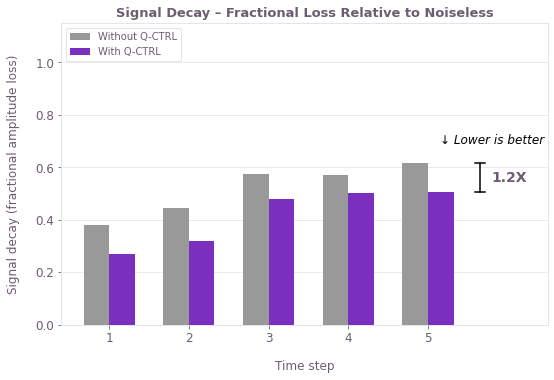

In [30]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(1, T_max + 1)
amp_raw = np.abs(signal_raw)
amp_fo = np.abs(signal_fo)
amp_sim = np.abs(signal_sim[:T_max])

decay_raw = 1 - amp_raw / amp_sim
decay_fo = 1 - amp_fo / amp_sim

fig, ax = plt.subplots(figsize=(8, 5.5))

bw = 0.32
x_left = steps - bw / 2
x_right = steps + bw / 2

ax.bar(x_left, decay_raw, bw, color="#999999", label="Without Q-CTRL", zorder=3)
ax.bar(x_right, decay_fo, bw, color="#7B2FBE", label="With Q-CTRL", zorder=3)

ax.axhline(0.0, color="k", ls="--", lw=1, alpha=0.4)


# Clean bracket on step 5
bx = 5 + 0.65
y_hi = decay_raw[-1]
y_lo = decay_fo[-1]
# Vertical line
ax.plot([bx, bx], [y_lo, y_hi], color="black", lw=1.5, clip_on=False)
# Horizontal ticks
ax.plot([bx - 0.06, bx + 0.06], [y_lo, y_lo], color="black", lw=1.5, clip_on=False)
ax.plot([bx - 0.06, bx + 0.06], [y_hi, y_hi], color="black", lw=1.5, clip_on=False)
# Ratio text
r_last = decay_raw[-1] / decay_fo[-1]
ax.text(
    bx + 0.15,
    (y_lo + y_hi) / 2,
    f"{r_last:.1f}X",
    fontsize=14,
    fontweight="bold",
    va="center",
)
ax.set_xlabel("Time step", fontsize=12)
ax.set_ylabel("Signal decay (fractional amplitude loss)", fontsize=12)
ax.text(
    bx - 0.5,
    y_hi + 0.06,
    "↓ Lower is better",
    fontsize=12,
    fontstyle="italic",
    color="black",
    va="bottom",
)
ax.set_title(
    "Signal Decay – Fractional Loss Relative to Noiseless",
    fontsize=13,
    fontweight="bold",
)
ax.set_xticks(steps)
ax.set_xlim(0.4, 6.5)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=10, loc="upper left")
ax.grid(axis="y", alpha=0.3, zorder=0)

plt.tight_layout()
plt.show()

## 5. Discussion

The hardware results show that Fire Opal improves the quality of the reconstructed QPDE signal for the 9-qubit Hubbard example. Across the five sampled time steps, the Fire Opal execution stays closer to the noiseless simulator reference than standard Qiskit execution. This difference is visible in the retained signal amplitude. With Fire Opal, the reconstructed signal preserves about 58% of the noiseless amplitude on average, compared with about 48% for standard Qiskit execution. In other words, Fire Opal preserves roughly 20% more of the signal amplitude over the sampled time window.

The improved signal retention shows that Fire Opal reduces noise-related signal damping and thereby provides longer, usable time series that provide a signal distinguishable from shot-noise or other systematic noise effects. [Kanno et al. (2026)](https://arxiv.org/abs/2601.15616) successfully applied Fire Opal to larger simulations. In their paper, you can find the full process including the downstream frequency analysis to recover the gap, and further refinements such as algorithmic error mitigation and iterative overlap enhancement push the method to larger systems. The signal-quality improvement shown here is what those longer experiments rely on at the hardware level, and extending the reconstruction to the full time window is where higher signal quality translates directly into a more accurate gap estimate.


In [3]:
from fireopal import print_package_versions

print_package_versions()

| Package               | Version |
| --------------------- | ------- |
| Python                | 3.12.11 |
| matplotlib            | 3.10.3  |
| networkx              | 3.2.1   |
| numpy                 | 2.3.0   |
| qiskit                | 2.3.1   |
| qiskit-ibm-runtime    | 0.40.1  |
| sympy                 | 1.14.0  |
| fire-opal             | 10.0.1  |
| qctrl-visualizer      | 9.0.0   |
| qctrl-workflow-client | 9.0.1   |
